# Customer Churn Prediction
## Phase 1: Data Exploration

### Import libraries


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)

### Load the dataset

In [2]:
df = pd.read_csv("../data/WA_Fn-UseC_-Telco-Customer-Churn.csv")

### Display the first rows


In [3]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


### Check the shape

In [4]:
df.shape

(7043, 21)

### Look at the columns

In [5]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

### Dataset information

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

### Stats

In [7]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [8]:
df.describe(include="object")

C:\Users\hlaku\AppData\Local\Temp\ipykernel_21324\702825166.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include="object")


,customerID,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,TotalCharges,Churn
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043
unique,7043,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,6531,2
top,7590-VHVEG,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,20.2,No
freq,1,3555,3641,4933,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,11,5174


### Missing values

In [9]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [10]:
(df == "").sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

### Duplicates

In [11]:
df.duplicated().sum()

np.int64(0)

### Target

In [12]:
df["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [13]:
df["Churn"].value_counts(normalize=True) * 100

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

## Phase 2: Exploratory Data Analysis (EDA)

#### This phase gives answers to:
 - Which customers churn the most?
 - Why do they churn?
 - WHich features seem most important?
 - What are the patterns?

### Import libraries

In [14]:
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (8,5)

### Churn Distribution

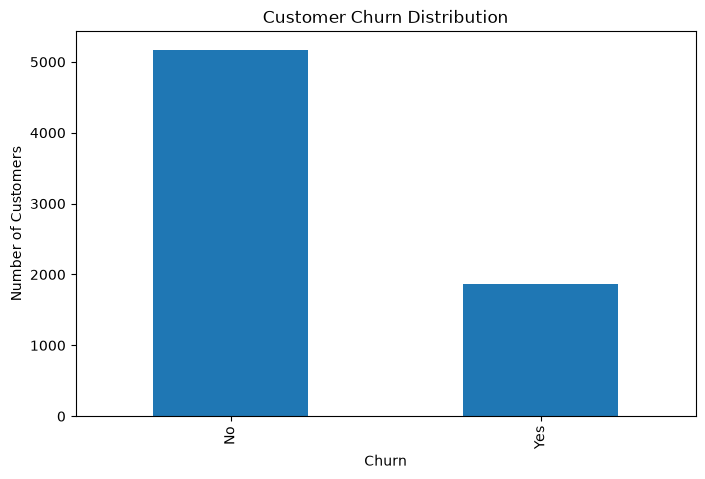

In [15]:
df["Churn"].value_counts().plot(kind="bar")

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

plt.show()

### Gender vs Churn

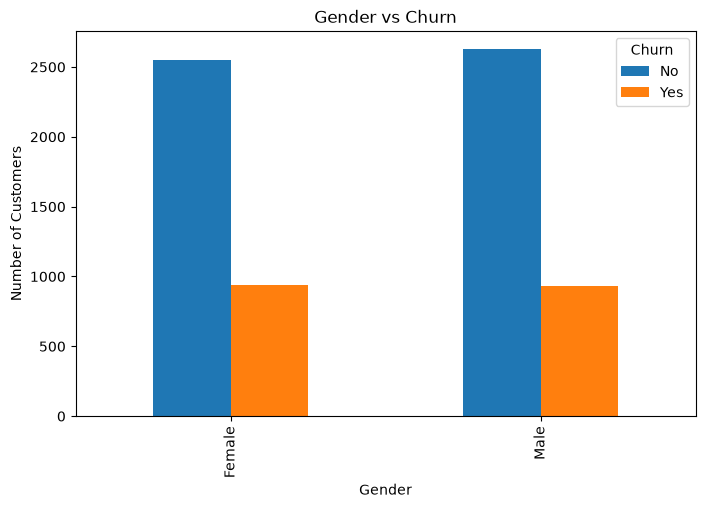

In [16]:
pd.crosstab(df["gender"], df["Churn"]).plot(kind="bar")

plt.title("Gender vs Churn")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")
plt.show()

### Senior Citizens

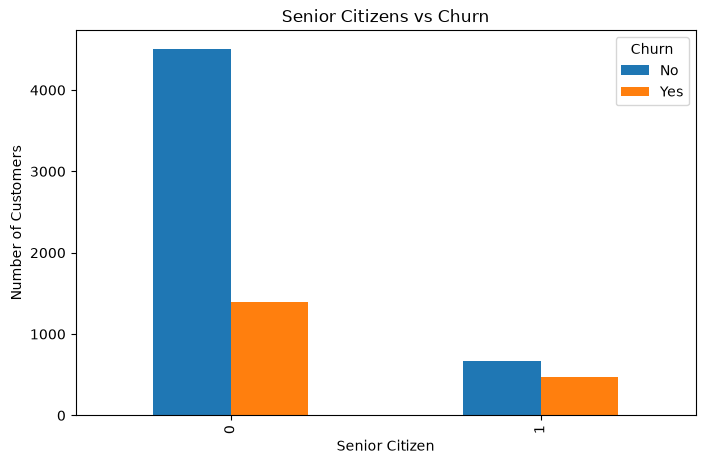

In [17]:
pd.crosstab(df["SeniorCitizen"], df["Churn"]).plot(kind="bar")

plt.title("Senior Citizens vs Churn")
plt.xlabel("Senior Citizen")
plt.ylabel("Number of Customers")
plt.show()

### Partner

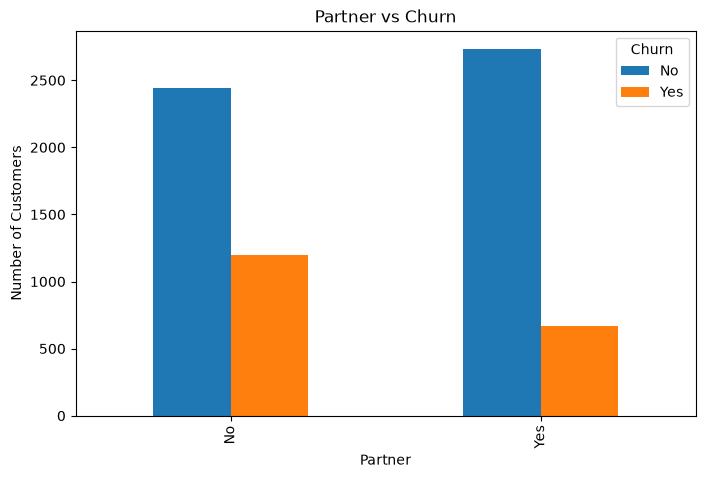

In [18]:
pd.crosstab(df["Partner"], df["Churn"]).plot(kind="bar")

plt.title("Partner vs Churn")
plt.xlabel("Partner")
plt.ylabel("Number of Customers")
plt.show()

### Dependents

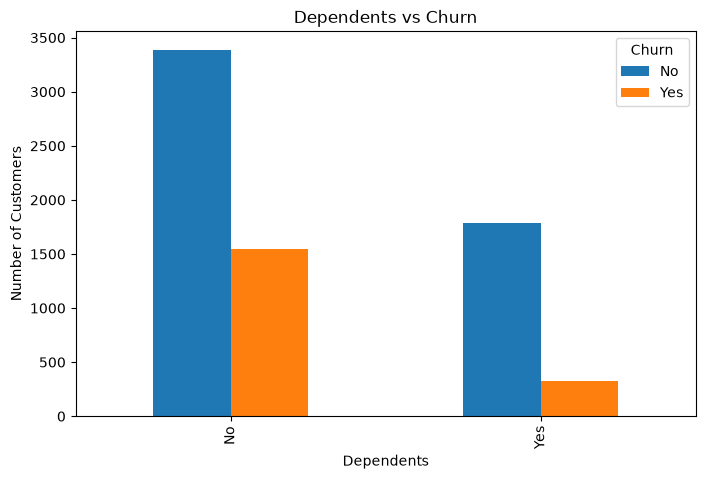

In [19]:
pd.crosstab(df["Dependents"], df["Churn"]).plot(kind="bar")

plt.title("Dependents vs Churn")
plt.xlabel("Dependents")
plt.ylabel("Number of Customers")
plt.show()

### Contract Type

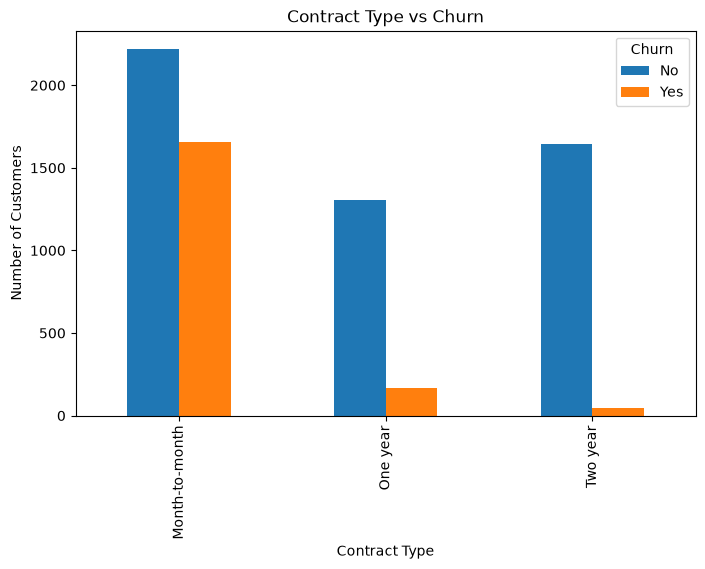

In [20]:
pd.crosstab(df["Contract"], df["Churn"]).plot(kind="bar")

plt.title("Contract Type vs Churn")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")
plt.show()

### Internet Service

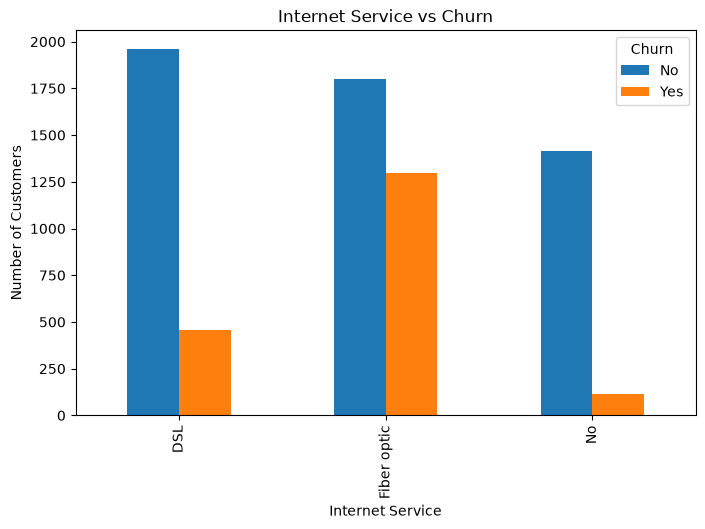

In [21]:
pd.crosstab(df["InternetService"], df["Churn"]).plot(kind="bar")

plt.title("Internet Service vs Churn")
plt.xlabel("Internet Service")
plt.ylabel("Number of Customers")
plt.show()

### Payment Method

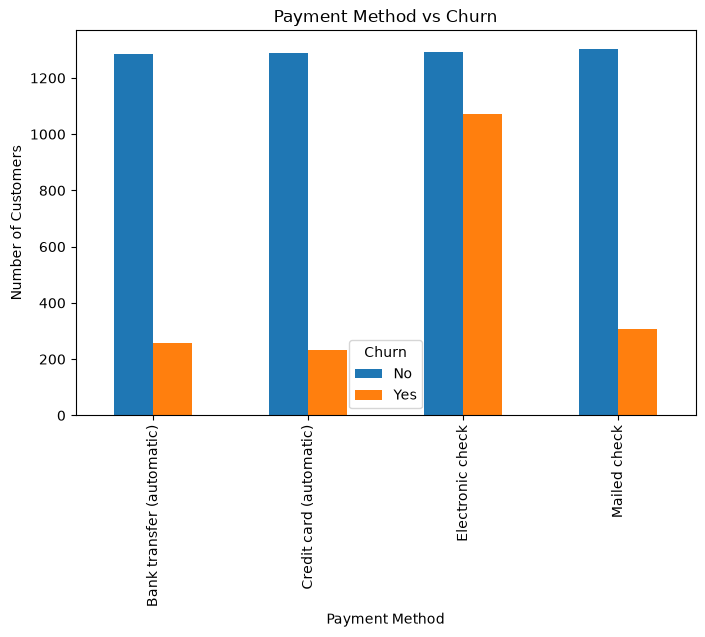

In [22]:
pd.crosstab(df["PaymentMethod"], df["Churn"]).plot(kind="bar")

plt.title("Payment Method vs Churn")
plt.xlabel("Payment Method")
plt.ylabel("Number of Customers")
plt.show()

### Paperless Billing

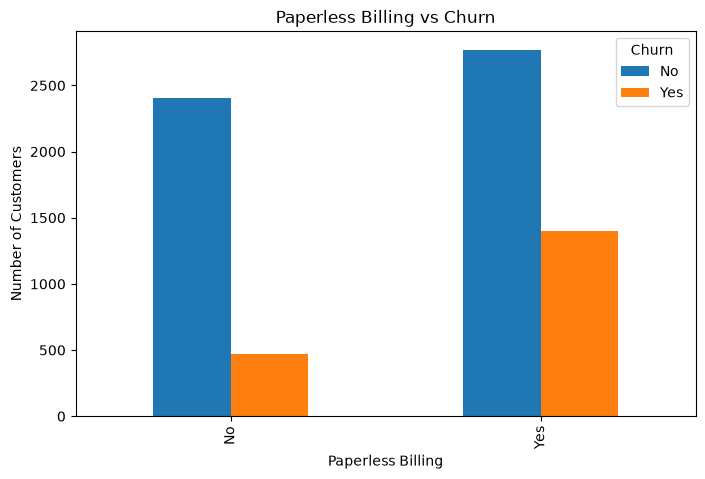

In [23]:
pd.crosstab(df["PaperlessBilling"], df["Churn"]).plot(kind="bar")

plt.title("Paperless Billing vs Churn")
plt.xlabel("Paperless Billing")
plt.ylabel("Number of Customers")
plt.show()

### Monthly CHarges

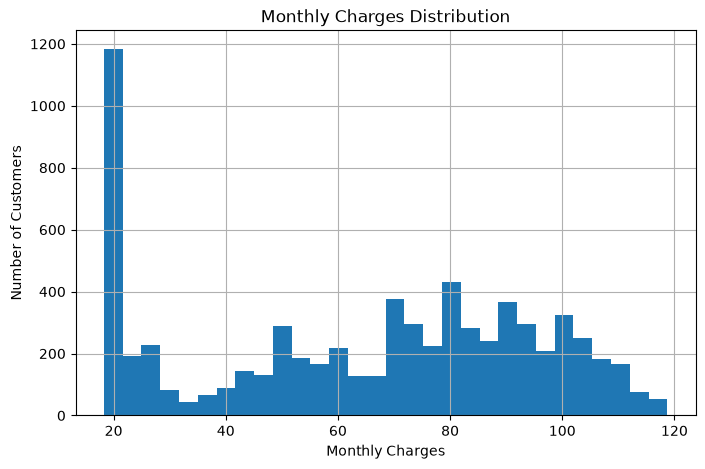

In [24]:
df["MonthlyCharges"].hist(bins=30)

plt.title("Monthly Charges Distribution")
plt.xlabel("Monthly Charges")
plt.ylabel("Number of Customers")

plt.show()

### Tenure

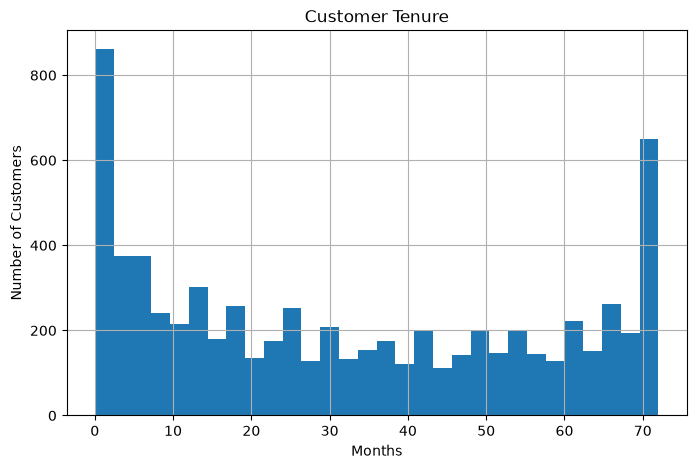

In [25]:
df["tenure"].hist(bins=30)

plt.title("Customer Tenure")
plt.xlabel("Months")
plt.ylabel("Number of Customers")

plt.show()

### Monthly Charges by Churn

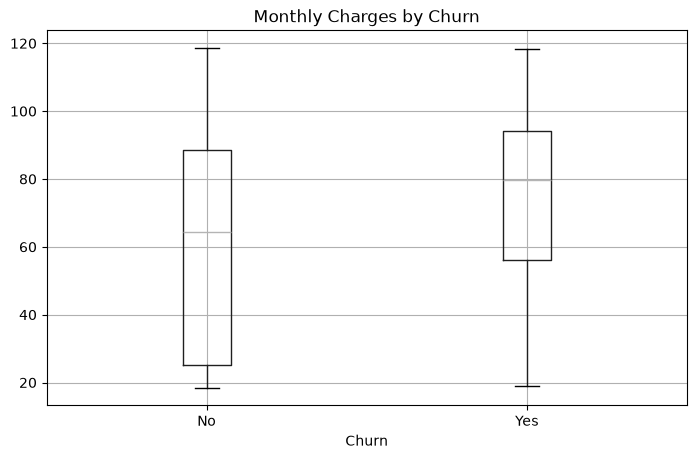

In [26]:
df.boxplot(column="MonthlyCharges", by="Churn")

plt.title("Monthly Charges by Churn")
plt.suptitle("")
plt.show()

### Tenure by Churn

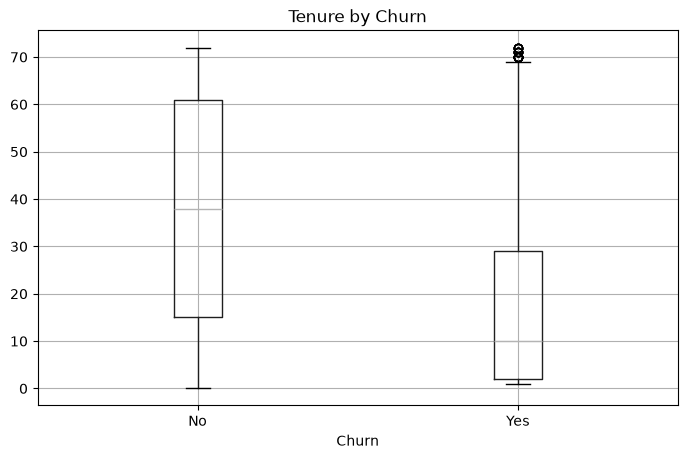

In [27]:
df.boxplot(column="tenure", by="Churn")

plt.title("Tenure by Churn")
plt.suptitle("")
plt.show()

### Correlation

In [28]:
numeric_df = df.select_dtypes(include=["number"])

numeric_df.corr()

,SeniorCitizen,tenure,MonthlyCharges
SeniorCitizen,1.000000,0.016567,0.220173
tenure,0.016567,1.000000,0.247900
MonthlyCharges,0.220173,0.247900,1.000000


Visualize

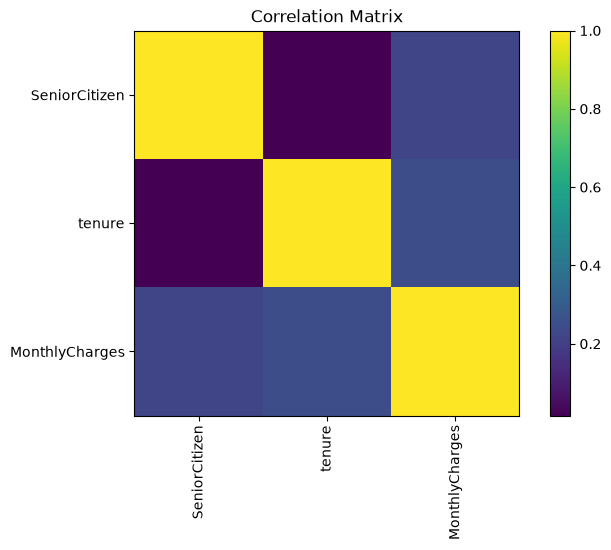

In [29]:
plt.imshow(numeric_df.corr())

plt.colorbar()

plt.xticks(
    range(len(numeric_df.columns)),
    numeric_df.columns,
    rotation=90
)

plt.yticks(
    range(len(numeric_df.columns)),
    numeric_df.columns
)

plt.title("Correlation Matrix")

plt.show()

## Phase 3: Data Preprocessing

#### Prepare the dataset for machine learning by:
- Removing unnecessary columns
- Fixing data types
- Handling missing values
- Encoding categorical variables
- Splitting features and target
- Splitting into training and test sets
- Scaling features

### Making a copy of the original dataframe

In [30]:
df_ml = df.copy()

### Remove Customer ID
Customer ID is unique for every customer, so it doesn't help predict the churn

In [31]:
df_ml.drop("customerID", axis=1, inplace=True)

### Fix Total Charges
Since it was store as text/str

In [32]:
df_ml["TotalCharges"].head()

0      29.85
1     1889.5
2     108.15
3    1840.75
4     151.65
Name: TotalCharges, dtype: str

In [33]:
df_ml["TotalCharges"] = pd.to_numeric(
    df_ml["TotalCharges"],
    errors="coerce"
)

In [34]:
df_ml.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   str    
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   str    
 3   Dependents        7043 non-null   str    
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   str    
 6   MultipleLines     7043 non-null   str    
 7   InternetService   7043 non-null   str    
 8   OnlineSecurity    7043 non-null   str    
 9   OnlineBackup      7043 non-null   str    
 10  DeviceProtection  7043 non-null   str    
 11  TechSupport       7043 non-null   str    
 12  StreamingTV       7043 non-null   str    
 13  StreamingMovies   7043 non-null   str    
 14  Contract          7043 non-null   str    
 15  PaperlessBilling  7043 non-null   str    
 16  PaymentMethod     7043 non-null   str    
 17  Monthl

### Missing Values

In [35]:
df_ml.isnull().sum()

gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [36]:
df_ml[df_ml["TotalCharges"].isnull()]

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,Male,0,No,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,Female,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


Simply remove the rows with missing values if any

In [37]:
df_ml.dropna(inplace=True)

In [38]:
df_ml.isnull().sum()

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

### Encode the target
Since in Machine learning models expect numbers, we must convert the targets to numbers (Yes -> 1 and No -> 0)

In [39]:
df_ml["Churn"] = df_ml["Churn"].map({
    "Yes":1,
    "No":0
})

Verify

In [40]:
df_ml["Churn"].value_counts()

Churn
0    5163
1    1869
Name: count, dtype: int64

### Encode Categorical Features


In [41]:
df_ml.select_dtypes(include="object").columns

C:\Users\hlaku\AppData\Local\Temp\ipykernel_21324\2125419566.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df_ml.select_dtypes(include="object").columns


Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='str')

In [42]:
df_ml = pd.get_dummies(
    df_ml,
    drop_first=True
)

Everything should be numeric

In [43]:
df_ml.info()

<class 'pandas.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 31 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   SeniorCitizen                          7032 non-null   int64  
 1   tenure                                 7032 non-null   int64  
 2   MonthlyCharges                         7032 non-null   float64
 3   TotalCharges                           7032 non-null   float64
 4   Churn                                  7032 non-null   int64  
 5   gender_Male                            7032 non-null   bool   
 6   Partner_Yes                            7032 non-null   bool   
 7   Dependents_Yes                         7032 non-null   bool   
 8   PhoneService_Yes                       7032 non-null   bool   
 9   MultipleLines_No phone service         7032 non-null   bool   
 10  MultipleLines_Yes                      7032 non-null   bool   
 11  InternetService_Fibe

### Separate Features and Target

In [44]:
X = df_ml.drop("Churn", axis=1)

y = df_ml["Churn"]

Verify

In [45]:
X.shape
y.shape

(7032,)

### Train/Test Split

In [46]:
from sklearn.model_selection import train_test_split

Split

In [47]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

Use "stratify=y" because it keeps the same churn/non-churn ratio in both training and test sets, giving a fairer evaluation.

### Scale Numeric Features
Some algorithms (like Logistic Regression) perform better when features are on a similar scale.

In [48]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

`fit_transform()` only on the training data and
`transform()` on the test data.

This prevents data leakage.

### Verify Shapes

In [49]:
print(X_train.shape)
print(X_test.shape)

print(y_train.shape)
print(y_test.shape)

(5625, 30)
(1407, 30)
(5625,)
(1407,)


## Phase 4: Model Training

### Here we train multiple classification models and compare their performance

- Logistic Regression
- Decision Tree
- Random Forest
- Gradient Boosting

### Import models

In [50]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier

### Create the models

In [51]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}

### Train the models

Logistic Regression uses the scaled data, while the tree-based models use the original data.

In [52]:
trained_models = {}

for name, model in models.items():

    if name == "Logistic Regression":
        model.fit(X_train_scaled, y_train)
    else:
        model.fit(X_train, y_train)

    trained_models[name] = model

print("All models trained successfully")

All models trained successfully


### Make predictions

In [53]:
predictions = {}

for name, model in trained_models.items():

    if name == "Logistic Regression":
        predictions[name] = model.predict(X_test_scaled)
    else:
        predictions[name] = model.predict(X_test)

### Save the models

In [54]:
import joblib
import os

os.makedirs("models", exist_ok=True)

for name, model in trained_models.items():
    filename = f"models/{name.replace(' ', '_').lower()}.pkl"
    joblib.dump(model, filename)

print("Models saved")

Models saved


## Phase 5: Model Evaluation

### Evaluate every model and determine the best one using multiple metrics

### We'll measure:
- Accuracy
- Precision
- Recall
- F1-score
- ROC-AUC Score
- Confusion Matrix

### Import evaluation metrics

In [55]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

### Create an empty results list

In [56]:
results = []

### Evaluate every model

In [57]:
for name, model in trained_models.items():

    if name == "Logistic Regression":
        y_pred = model.predict(X_test_scaled)
        y_prob = model.predict_proba(X_test_scaled)[:,1]
    else:
        y_pred = model.predict(X_test)
        y_prob = model.predict_proba(X_test)[:,1]

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc = roc_auc_score(y_test, y_prob)

    results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "ROC-AUC": roc
    })

### Create a results table

In [58]:
results_df = pd.DataFrame(results)

results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.803838,0.647590,0.574866,0.609065,0.835673
1,Decision Tree,0.718550,0.470109,0.462567,0.466307,0.636638
2,Random Forest,0.789623,0.625806,0.518717,0.567251,0.816490
3,Gradient Boosting,0.795309,0.637821,0.532086,0.580175,0.840662


### Sort by performance

In [59]:
results_df.sort_values(
    by="ROC-AUC",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
3,Gradient Boosting,0.795309,0.637821,0.532086,0.580175,0.840662
0,Logistic Regression,0.803838,0.647590,0.574866,0.609065,0.835673
2,Random Forest,0.789623,0.625806,0.518717,0.567251,0.816490
1,Decision Tree,0.718550,0.470109,0.462567,0.466307,0.636638


Why ROC-AUC?

Because it measures how well the model separates churners from non-churners across all thresholds, making it especially useful for comparing classifiers.

### Classification report

In [60]:
for name, model in trained_models.items():

    if name == "Logistic Regression":
        y_pred = model.predict(X_test_scaled)
    else:
        y_pred = model.predict(X_test)

    print("="*50)
    print(name)
    print("="*50)

    print(classification_report(y_test, y_pred))

Logistic Regression
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1033
           1       0.65      0.57      0.61       374

    accuracy                           0.80      1407
   macro avg       0.75      0.73      0.74      1407
weighted avg       0.80      0.80      0.80      1407

Decision Tree
              precision    recall  f1-score   support

           0       0.81      0.81      0.81      1033
           1       0.47      0.46      0.47       374

    accuracy                           0.72      1407
   macro avg       0.64      0.64      0.64      1407
weighted avg       0.72      0.72      0.72      1407

Random Forest
              precision    recall  f1-score   support

           0       0.84      0.89      0.86      1033
           1       0.63      0.52      0.57       374

    accuracy                           0.79      1407
   macro avg       0.73      0.70      0.71      1407
weighted avg       0.78   

### Confusion Matrix

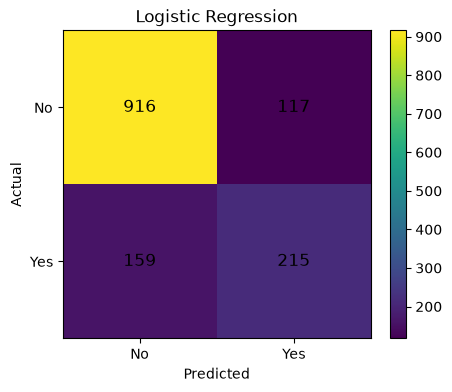

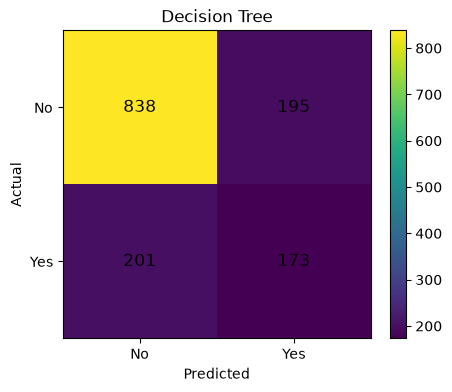

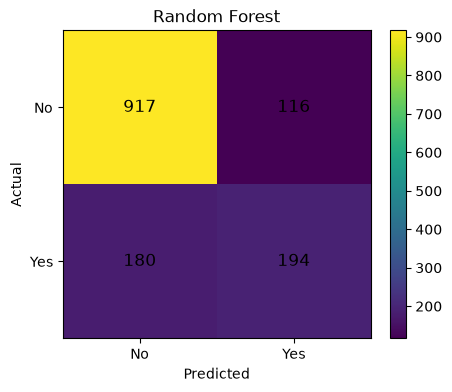

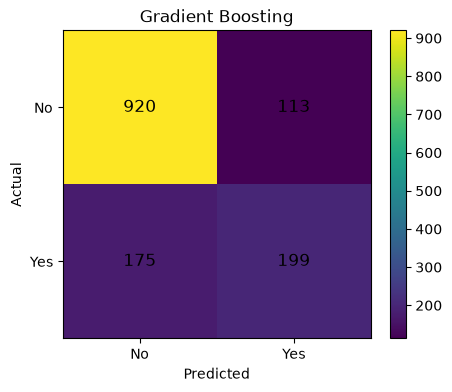

In [61]:
for name, model in trained_models.items():

    if name == "Logistic Regression":
        y_pred = model.predict(X_test_scaled)
    else:
        y_pred = model.predict(X_test)

    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(5,4))

    plt.imshow(cm)

    plt.title(name)

    plt.colorbar()

    plt.xlabel("Predicted")

    plt.ylabel("Actual")

    plt.xticks([0,1],["No","Yes"])

    plt.yticks([0,1],["No","Yes"])

    for i in range(2):
        for j in range(2):
            plt.text(j,i,cm[i,j],
                    ha="center",
                    va="center",
                    fontsize=12)

    plt.show()

### Save the results

In [62]:
results_df.to_csv(
    "model_comparison.csv",
    index=False
)

## Phase 6: Feature Importance and Business Insights

### Goal:
Answer: 
- Which features matter the most?
- Why are customers leaving?
- What should the business do?

### Pick the best model

In [63]:
best_model_name = results_df.sort_values(by="ROC-AUC", ascending=False).iloc[0]["Model"]
best_model = trained_models[best_model_name]

print(f"Best model based on ROC-AUC: {best_model_name}")

Best model based on ROC-AUC: Gradient Boosting


### Extract Feature Importance

Tree-based models (Random Forest, Gradient Boosting) expose a `feature_importances_` attribute that tells us how much each feature contributed to reducing impurity across all the trees. Since our best model is Gradient Boosting, we use that.

In [64]:
importances = pd.Series(
    best_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

top_features = importances.head(10)
top_features

tenure                                0.317935
InternetService_Fiber optic           0.190840
PaymentMethod_Electronic check        0.104797
Contract_Two year                     0.069253
TotalCharges                          0.068000
MonthlyCharges                        0.060465
Contract_One year                     0.056423
OnlineSecurity_Yes                    0.019964
PaperlessBilling_Yes                  0.015872
OnlineSecurity_No internet service    0.015626
dtype: float64

### Visualize Top 10 Features

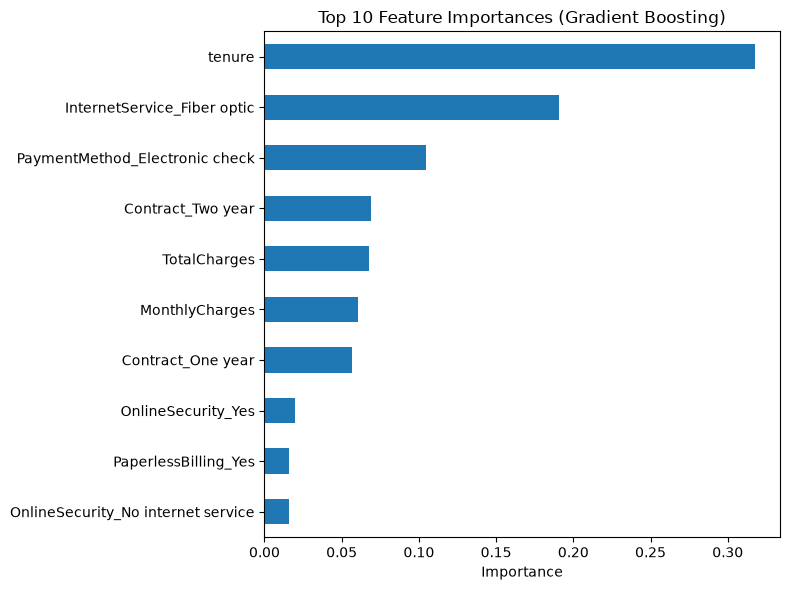

In [65]:
plt.figure(figsize=(8,6))

top_features.sort_values().plot(kind="barh")

plt.title(f"Top 10 Feature Importances ({best_model_name})")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

### Insight 1 — Which features matter the most?

The actual feature importances from the Gradient Boosting model tell a slightly different story than the raw EDA charts alone:

- **Tenure** is the single strongest predictor by a clear margin (importance ≈ 0.32). How long someone has been a customer matters more to the model than any other factor.
- **Fiber optic internet service** is the second strongest driver (≈ 0.19) — despite being the premium product, it's strongly associated with churn.
- **Electronic check** as a payment method is the third strongest driver (≈ 0.10) — clearly stronger than the EDA bar chart alone suggested.
- **Contract length** (`Contract_Two year`, `Contract_One year`) and **billing amounts** (`TotalCharges`, `MonthlyCharges`) form the next tier of importance (roughly 0.06–0.07 each) — still meaningful, but secondary to tenure, internet type, and payment method.
- **Online Security** (having it, or having no internet service at all) and **Paperless Billing** round out the top 10, each contributing a smaller but non-trivial amount.

So while the EDA in Phase 2 highlighted contract type as visually the most dramatic split, the model itself weighs **tenure, internet type, and payment method** more heavily once all features are considered together.

### Insight 2 — Why are customers leaving?

Putting the feature importances together with the EDA findings from Phase 2, a clear churn profile emerges:

> **The highest-risk customer is new (low tenure), subscribed to Fiber optic internet, pays via electronic check, and is on a flexible month-to-month contract.**

This makes intuitive business sense:
- **Early-tenure risk dominates.** Tenure is the model's single biggest signal — customers haven't yet built up a relationship, habits, or switching friction with the company, so they're the easiest to lose.
- **Fiber optic dissatisfaction.** This is a premium, higher-priced product, yet it shows the second-highest importance for churn — pointing to a gap between price/expectations and the actual experience (reliability, support, or perceived value).
- **Electronic check as a behavioral marker.** This payment method ranks above contract type itself. It's likely a proxy for a broader pattern — customers who haven't set up automatic billing may also be less embedded/committed to the service overall.
- **Low commitment, low switching cost.** Month-to-month customers still have no penalty for leaving, which is why contract type remains an important (if secondary) factor.
- **Weaker safety net.** Customers without Online Security have one less reason to stay engaged with the broader service ecosystem.

### Insight 3 — What should the business do?

Based on these findings, the following actions are recommended, roughly in order of expected impact:

1. **Launch a new-customer retention program.** Since tenure is the single biggest churn driver, invest in proactive onboarding, early check-ins, or a "first 90 days" engagement plan — this is the highest-leverage area to act on.
2. **Audit the Fiber optic experience.** Investigate whether churn among Fiber optic customers is driven by price, network reliability, or customer support, since it's the second strongest churn signal in the model and a large, high-value segment to lose.
3. **Review electronic check billing friction.** This payment method is a stronger churn signal than contract type itself — encourage migration to automatic payment methods (credit card / bank transfer), possibly through a small incentive.
4. **Incentivize longer contracts.** Offer discounts or loyalty pricing to move month-to-month customers onto one- or two-year contracts — still an effective, if secondary, lever.
5. **Bundle in protective add-ons.** Promote Online Security (and similar support services) for new and month-to-month customers, since the data shows it correlates with lower churn.
6. **Deploy the model operationally.** Use the trained Gradient Boosting model to score the active customer base monthly and flag high-risk customers for proactive retention outreach, prioritizing customers with high predicted churn probability and high `MonthlyCharges` (highest revenue at risk).

---
### Summary

This project built and compared four classification models to predict customer churn for a telecom provider. **Gradient Boosting** was selected as the best-performing model with a **ROC-AUC of 0.84**, narrowly ahead of Logistic Regression. Feature importance analysis revealed that **tenure, Fiber optic internet service, and electronic check payment method** are the leading drivers of churn — with contract length and billing amounts forming a meaningful second tier. Translating these into action — strengthening early-tenure engagement, reviewing the Fiber optic offering, and reducing billing friction — gives the business a concrete, data-driven roadmap to reduce churn and protect recurring revenue.